# Análisis de series temporales en mercados financieros — SPX y DAX

**Objetivo.** Explorar el comportamiento conjunto de dos índices bursátiles de referencia
(S&P 500 y DAX) sobre 6.269 observaciones diarias entre enero de 1994 y enero de 2018,
con foco en el impacto de la crisis financiera de 2008.

**Técnicas.** Tratamiento de series temporales con pandas, indexación temporal,
análisis de estacionariedad y visualización comparada de índices.

**Stack.** Python · pandas · numpy · matplotlib

---

In [1]:
from google.colab import files
uploaded = files.upload ()

Saving Index2018.csv to Index2018 (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [3]:
# ============================================================
# CARGA DEL FICHERO
# Detecta automáticamente el archivo y su formato (CSV o XLSX)
# ============================================================
import os

# Buscamos el fichero en el directorio de trabajo de Colab
archivos = [f for f in os.listdir() if f.lower().startswith('index2018')]
print('Archivos detectados:', archivos)

nombre = archivos[0]

if nombre.lower().endswith('.csv'):
    df = pd.read_csv(nombre)
    # Si solo lee 1 columna, el separador no era la coma:
    # Excel en configuración española exporta con punto y coma
    if df.shape[1] == 1:
        df = pd.read_csv(nombre, sep=';', decimal=',')
else:
    df = pd.read_excel(nombre)

print('\nDimensiones:', df.shape)   # Esperado: (6269, 5)
df.head()

Archivos detectados: ['Index2018 (1).csv', 'Index2018.csv', 'Index2018 (2).csv']

Dimensiones: (6269, 5)


,date,spx,dax,ftse,nikkei
0,1994-01-07,469.90,"2,224.95","3,445.98","18,124.01"
1,1994-01-10,475.27,"2,225.00","3,440.58","18,443.44"
2,1994-01-11,474.13,"2,228.10","3,413.77","18,485.25"
3,1994-01-12,474.17,"2,182.06","3,372.02","18,793.88"
4,1994-01-13,472.47,"2,142.37","3,360.01","18,577.26"


In [4]:
# ============================================================
# DIAGNÓSTICO DE TIPOS (paso 4 del enunciado)
# Un CSV es texto plano y no guarda el tipo de dato:
# 'date' aparecerá como object (texto), no como fecha
# ============================================================
print('--- TIPOS ORIGINALES ---')
print(df.dtypes)

--- TIPOS ORIGINALES ---
date       object
spx       float64
dax       float64
ftse      float64
nikkei    float64
dtype: object


In [5]:
# ============================================================
# CONVERSIÓN DE TIPOS
# ============================================================

# Texto -> fecha real. Sin esto '2008-01-15' es una cadena
# y pandas no sabe que va después de '2007-12-31'
df['date'] = pd.to_datetime(df['date'])

# Forzamos float en los 4 índices.
# errors='coerce': si algo no se puede convertir lo pone a NaN
# en vez de romper la ejecución -> lo detectamos abajo
for col in ['spx', 'dax', 'ftse', 'nikkei']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

print('--- TIPOS CORREGIDOS ---')
print(df.dtypes)

# Control de calidad: si la conversión falló, aquí saldrían nulos
print('\nNulos:'); print(df.isna().sum())
print('Duplicados:', df.duplicated().sum())

--- TIPOS CORREGIDOS ---
date      datetime64[ns]
spx              float64
dax              float64
ftse             float64
nikkei           float64
dtype: object

Nulos:
date      0
spx       0
dax       0
ftse      0
nikkei    0
dtype: int64
Duplicados: 0


In [6]:
# ============================================================
# FECHA COMO ÍNDICE — el paso clave del bloque
# Habilita filtrar con df.loc['2008'] y usar rolling()/resample()
# ============================================================
df = df.set_index('date').sort_index()   # sort_index garantiza orden cronológico

print('Tipo de índice:', type(df.index).__name__)   # Esperado: DatetimeIndex
print('Desde:', df.index.min().date(), '| Hasta:', df.index.max().date())
print('Observaciones:', len(df))   # 6269 (solo días hábiles, no naturales)
df.head()

Tipo de índice: DatetimeIndex
Desde: 1994-01-07 | Hasta: 2018-01-29
Observaciones: 6269


,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,"2,224.95","3,445.98","18,124.01"
1994-01-10,475.27,"2,225.00","3,440.58","18,443.44"
1994-01-11,474.13,"2,228.10","3,413.77","18,485.25"
1994-01-12,474.17,"2,182.06","3,372.02","18,793.88"
1994-01-13,472.47,"2,142.37","3,360.01","18,577.26"


El DataFrame contiene **6.269 observaciones diarias** entre el 7 de enero de 1994 y el 29 de enero de 2018, sin valores ausentes ni duplicados, con `date` correctamente definido como DatetimeIndex.

La serie recoge únicamente **días hábiles bursátiles**: no existen registros en fines de semana ni festivos, por lo que la frecuencia no es diaria natural. Es el comportamiento esperado en datos de mercado y explica que haya 6.269 observaciones y no las aproximadamente 8.800 que tendrían 24 años naturales.

## 5. Visualización de SPX y DAX

Se representa la evolución de ambos índices en todo el período disponible y, a continuación, se filtra el año 2008 para observar el impacto de la crisis bancaria global.

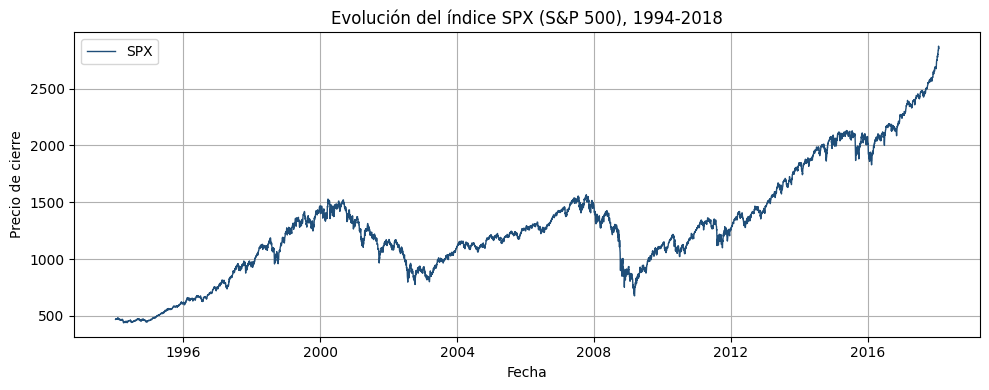

In [7]:
# ============================================================
# SPX: SERIE COMPLETA 1994-2018
# Esta gráfica es la evidencia visual de la NO ESTACIONARIEDAD
# en media: la serie nunca revierte a un nivel de referencia
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['spx'], label='SPX', color='#1f4e79', linewidth=1)  # línea fina: 6.269 puntos
plt.title('Evolución del índice SPX (S&P 500), 1994-2018')
plt.xlabel('Fecha'); plt.ylabel('Precio de cierre')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

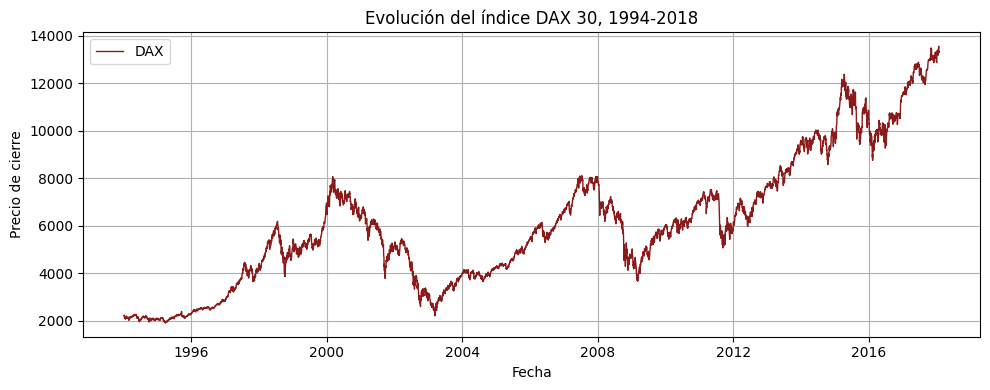

In [8]:
# ============================================================
# DAX: SERIE COMPLETA (mismo gráfico para el segundo índice)
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['dax'], label='DAX', color='#8b1a1a', linewidth=1)
plt.title('Evolución del índice DAX 30, 1994-2018')
plt.xlabel('Fecha'); plt.ylabel('Precio de cierre')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

Observaciones en 2008: 261


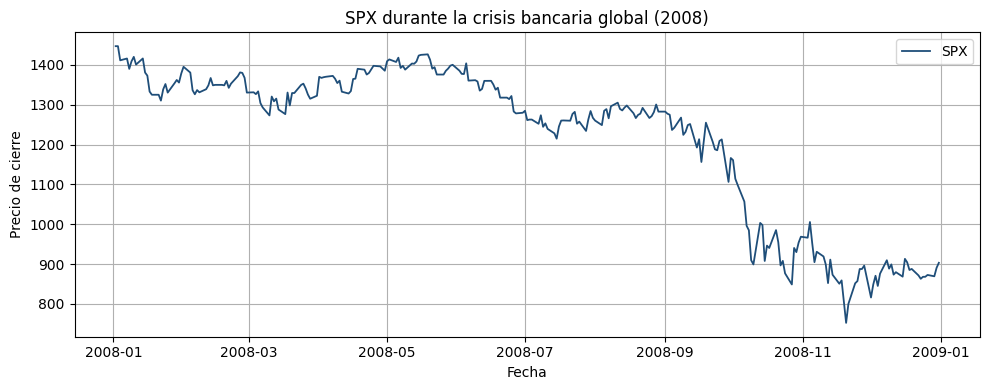

In [9]:
# ============================================================
# FILTRADO DEL AÑO 2008 — crisis bancaria global
# df.loc['2008'] funciona gracias al DatetimeIndex de la celda 7
# ============================================================
df_2008 = df.loc['2008']
print('Observaciones en 2008:', len(df_2008))   # 261 sesiones

plt.figure(figsize=(10, 4))
plt.plot(df_2008.index, df_2008['spx'], label='SPX', color='#1f4e79', linewidth=1.3)
plt.title('SPX durante la crisis bancaria global (2008)')
plt.xlabel('Fecha'); plt.ylabel('Precio de cierre')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()
# El desplome de septiembre coincide con la quiebra de Lehman (15/09/2008)

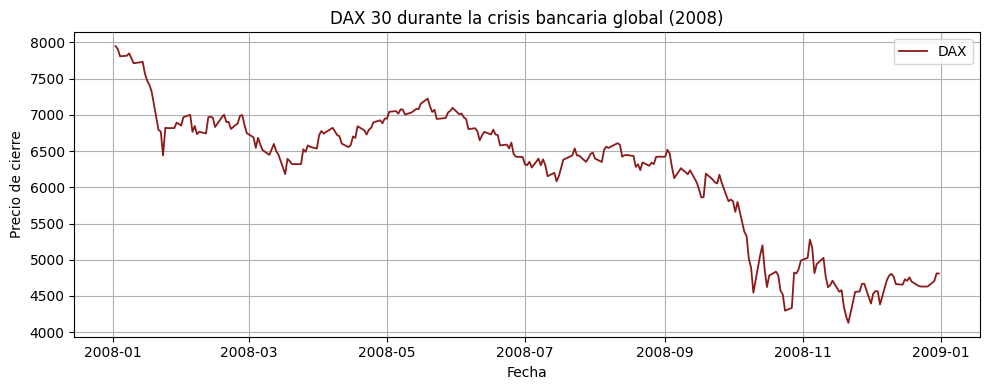

In [10]:
# ============================================================
# DAX 2008 — mismo filtrado para el índice alemán
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(df_2008.index, df_2008['dax'], label='DAX', color='#8b1a1a', linewidth=1.3)
plt.title('DAX 30 durante la crisis bancaria global (2008)')
plt.xlabel('Fecha'); plt.ylabel('Precio de cierre')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# CUANTIFICACIÓN DE LA CAÍDA DE 2008
# max() da el VALOR máximo; idxmax() da la FECHA en que ocurrió
# ============================================================
for col, idx in [('spx', 'SPX'), ('dax', 'DAX')]:
    s = df_2008[col]
    caida = (s.min() / s.max() - 1) * 100   # variación % del máximo al mínimo
    print(f'{idx}: máx {s.max():,.2f} ({s.idxmax().date()}) | '
          f'mín {s.min():,.2f} ({s.idxmin().date()}) | caída {caida:.2f}%')

# RESULTADO CLAVE: SPX -48,01% y DAX -48,08%, con mínimos
# separados por un solo día. Dos mercados distintos, misma caída
# -> evidencia de integración de los mercados internacionales

SPX: máx 1,447.16 (2008-01-03) | mín 752.44 (2008-11-20) | caída -48.01%
DAX: máx 7,949.11 (2008-01-02) | mín 4,127.41 (2008-11-21) | caída -48.08%


## 6. Análisis descriptivo de las variables

In [12]:
# ============================================================
# ESTADÍSTICOS DESCRIPTIVOS (paso 6 del enunciado)
# ============================================================
df[['spx', 'dax']].describe()

# Fíjate: la MEDIA supera a la MEDIANA en ambos índices
# -> asimetría positiva (se desarrolla en la celda de texto)

,spx,dax
count,"6,269.00","6,269.00"
mean,"1,288.13","6,080.06"
std,487.59,"2,754.36"
min,438.92,"1,911.70"
25%,990.67,"4,069.35"
50%,"1,233.42","5,773.34"
75%,"1,459.99","7,443.07"
max,"2,872.87","13,559.60"


In [13]:
# ============================================================
# TABLA AMPLIADA: describe() no incluye IQR ni coef. de variación
# ============================================================
resumen = pd.DataFrame({
    'Media':        df[['spx','dax']].mean(),
    'Mediana':      df[['spx','dax']].median(),
    'Desv. típica': df[['spx','dax']].std(),
    'Mínimo':       df[['spx','dax']].min(),
    'Máximo':       df[['spx','dax']].max(),
    'Q1':           df[['spx','dax']].quantile(0.25),
    'Q3':           df[['spx','dax']].quantile(0.75),
})

# IQR: rango que ocupa el 50% central de los datos
resumen['IQR'] = resumen['Q3'] - resumen['Q1']

# CV: dispersión relativa. Imprescindible aquí, porque la desv. típica
# absoluta no es comparable entre índices de distinta escala
# (DAX cotiza ~6.000 puntos y SPX ~1.300)
resumen['Coef. variación (%)'] = resumen['Desv. típica'] / resumen['Media'] * 100

# Asimetría: cuantifica lo que ya se intuye al comparar media y mediana
resumen['Asimetría'] = df[['spx','dax']].skew()

resumen.T   # transponemos para que se lea mejor

,spx,dax
Media,"1,288.13","6,080.06"
Mediana,"1,233.42","5,773.34"
Desv. típica,487.59,"2,754.36"
Mínimo,438.92,"1,911.70"
Máximo,"2,872.87","13,559.60"
Q1,990.67,"4,069.35"
Q3,"1,459.99","7,443.07"
IQR,469.32,"3,373.72"
Coef. variación (%),37.85,45.30
Asimetría,0.63,0.62


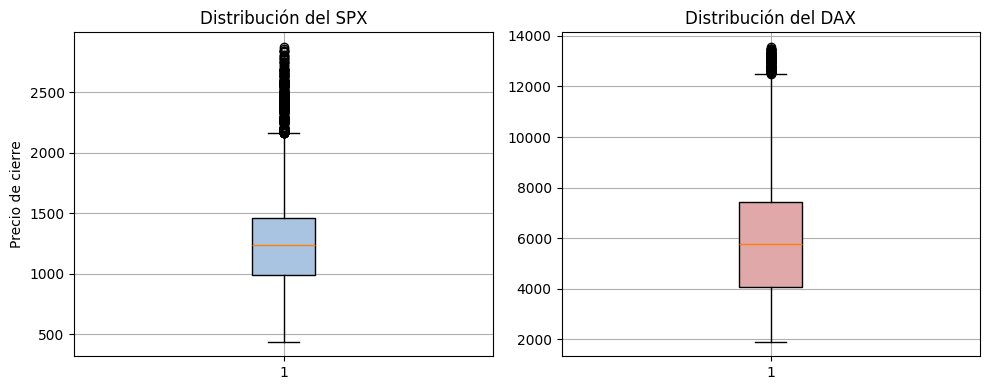

In [14]:
# ============================================================
# DIAGRAMAS DE CAJA
# La caja = IQR (Q1 a Q3) | línea interior = mediana
# Bigotes = 1,5 x IQR | puntos sueltos = atípicos de Tukey
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))   # 2 gráficos en una fila

axes[0].boxplot(df['spx'], patch_artist=True, boxprops=dict(facecolor='#a8c4e0'))
axes[0].set_title('Distribución del SPX'); axes[0].set_ylabel('Precio de cierre')

axes[1].boxplot(df['dax'], patch_artist=True, boxprops=dict(facecolor='#e0a8a8'))
axes[1].set_title('Distribución del DAX')

plt.tight_layout(); plt.show()
# La mediana no está centrada en la caja: asimetría positiva visual

In [15]:
# ============================================================
# OUTLIERS — criterio de Tukey (1,5 x IQR)
# Versión numérica de lo que el boxplot muestra visualmente
# ============================================================
print('OUTLIERS — criterio de Tukey (1,5 x IQR)\n')
for col, idx in [('spx','SPX'), ('dax','DAX')]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    inf, sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    at = df[(df[col] < inf) | (df[col] > sup)]   # '|' = "o" lógico en pandas
    print(f'{idx}: límites [{inf:,.2f} ; {sup:,.2f}] -> {len(at)} atípicos ({len(at)/len(df)*100:.2f}%)')
    if len(at) > 0:
        # El CUÁNDO es lo que convierte un número en un hallazgo:
        print(f'   Rango temporal: {at.index.min().date()} a {at.index.max().date()}\n')

# HALLAZGO: todos los atípicos están en 2016-2018 y todos por ARRIBA.
# No son anomalías: son los máximos históricos recientes.
# Y NO detecta ni 2008 ni las puntocom, los dos peores desplomes.
# Motivo: Tukey asume datos i.i.d., y una serie con tendencia lo incumple.
# -> Las anomalías financieras se detectan sobre RENDIMIENTOS, no niveles.

OUTLIERS — criterio de Tukey (1,5 x IQR)

SPX: límites [286.70 ; 2,163.96] -> 357 atípicos (5.69%)
   Rango temporal: 2016-07-18 a 2018-01-29

DAX: límites [-991.23 ; 12,503.65] -> 145 atípicos (2.31%)
   Rango temporal: 2017-05-02 a 2018-01-29



Correlación de Pearson SPX-DAX: 0.9719


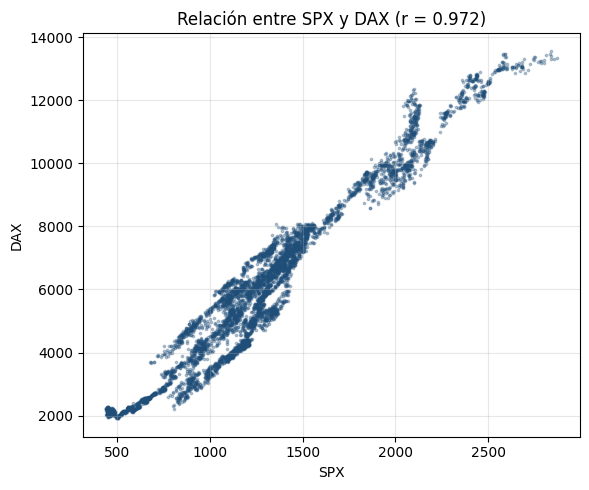

In [16]:
# ============================================================
# CORRELACIÓN ENTRE AMBOS ÍNDICES
# ============================================================
r = df['spx'].corr(df['dax'])   # Pearson: relación lineal, escala -1 a +1
print(f'Correlación de Pearson SPX-DAX: {r:.4f}')

plt.figure(figsize=(6, 5))
# s=3 y alpha=0.3: con 6.269 puntos, sin transparencia sería una mancha
plt.scatter(df['spx'], df['dax'], s=3, alpha=0.3, color='#1f4e79')
plt.title(f'Relación entre SPX y DAX (r = {r:.3f})')
plt.xlabel('SPX'); plt.ylabel('DAX')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# CAUTELA: r=0,97 es en buena parte ESPURIA. Dos series con tendencia
# creciente correlacionan mucho aunque no haya relación económica.
# La integración real de mercados la demuestra la sincronía de 2008.

### Interpretación de los resultados

**Tendencia de crecimiento**

Ambas series muestran una tendencia alcista sostenida de largo plazo. El SPX pasa de 469,90 puntos en enero de 1994 a 2.853,53 en enero de 2018, y el DAX de 2.224,95 a 13.324,48 en el mismo intervalo: una revalorización superior al 500% en ambos casos. La tendencia no es lineal ni monótona, ya que se identifican tres fases expansivas separadas por dos correcciones severas.

**Relación entre media y mediana**

| Estadístico | SPX | DAX |
|---|---|---|
| Media | 1.288,13 | 6.080,06 |
| Mediana | 1.233,42 | 5.773,34 |

En ambos índices la media supera a la mediana, lo que indica una **distribución asimétrica positiva**. Los coeficientes de asimetría lo confirman: 0,630 para el SPX y 0,623 para el DAX, valores prácticamente idénticos.

La explicación es económica, no estadística: los valores extremos alcanzados en los últimos años del período arrastran la media al alza sin desplazar la mediana en la misma medida. En una serie con tendencia creciente, la asimetría positiva es la consecuencia natural de que el activo pase la mayor parte del tiempo en niveles inferiores a sus máximos históricos.

**Dispersión**

La desviación típica absoluta no es comparable entre ambos índices porque operan en escalas distintas: 487,59 puntos en el SPX frente a 2.754,36 en el DAX. La medida adecuada para comparar es el **coeficiente de variación**, que relativiza la dispersión respecto a la media:

- SPX: 37,85%
- DAX: 45,30%

El DAX presenta una dispersión relativa notablemente superior, coherente con lo esperado en un índice de solo 30 valores frente a los 500 del S&P 500. Su menor diversificación y su concentración sectorial en industria, automoción y química lo hacen estructuralmente más volátil.

El rango intercuartílico apunta en la misma dirección: 469,32 puntos en el SPX sobre una mediana de 1.233,42 (un 38,0%), frente a 3.373,72 en el DAX sobre una mediana de 5.773,34 (un 58,4%).

**Valores atípicos**

El criterio de Tukey identifica 357 observaciones atípicas en el SPX (5,69% de la muestra) y 145 en el DAX (2,31%). El dato relevante no es su número sino **su localización temporal**: en el SPX se concentran entre julio de 2016 y enero de 2018, y en el DAX entre mayo de 2017 y enero de 2018. Todas superan el límite superior; ninguna queda por debajo del inferior.

Esto obliga a una matización de fondo: lo que el test detecta no son anomalías, sino **el tramo final de la tendencia alcista**. Las observaciones señaladas son los máximos históricos de los últimos meses de la serie, extremos únicamente porque se comparan con niveles de precio de hace veinte años.

El resultado es aún más llamativo por lo que **no** detecta: ni el desplome de 2008 ni el estallido de las puntocom aparecen como atípicos, pese a ser los dos eventos más severos del período. Al situarse en niveles intermedios dentro del recorrido histórico total, quedan holgadamente dentro del rango intercuartílico.

La explicación es metodológica. El criterio de Tukey presupone observaciones independientes e idénticamente distribuidas, condición que una serie temporal con tendencia incumple por definición. Aplicado sobre niveles de precio, mide posición dentro de la trayectoria histórica, no comportamiento anómalo. **Para detectar anomalías en datos financieros el análisis debe realizarse sobre los rendimientos, no sobre los niveles.**

**Eventos relevantes identificados**

| Período | Evento | Efecto observado |
|---|---|---|
| 1994-2000 | Expansión de las puntocom | Fuerte revalorización; el DAX supera los 8.000 puntos en marzo de 2000 |
| 2000-2003 | Estallido de la burbuja tecnológica | Corrección prolongada; el DAX cae por debajo de 2.200 puntos en marzo de 2003 |
| 2003-2007 | Ciclo expansivo pre-crisis | Recuperación sostenida hasta máximos de 2007 |
| **2008** | **Crisis financiera global** | **Caída del 48,01% en el SPX y del 48,08% en el DAX entre máximo y mínimo anual** |
| 2009-2018 | Expansión con política monetaria acomodaticia | Ciclo alcista más prolongado del período |

El dato de 2008 resulta especialmente revelador: la caída es prácticamente idéntica en ambos índices pese a tratarse de mercados y economías distintas. El SPX marca su mínimo el 20 de noviembre de 2008 y el DAX el 21 de noviembre, con un solo día de diferencia.

**Comparación entre ambos índices**

La correlación de Pearson entre SPX y DAX alcanza 0,9719, un valor muy elevado que debe interpretarse con cautela: buena parte es **espuria**, atribuible a que ambas series comparten una tendencia creciente común. Dos series con tendencia al alza correlacionan fuertemente aunque no exista relación económica entre ellas.

Dicho esto, la sincronía de la caída de 2008 sí evidencia una integración real de los mercados financieros internacionales. Desde mi experiencia en banca privada, este es precisamente el argumento que justifica que la diversificación geográfica dentro de renta variable desarrollada aporte mucho menos de lo que el cliente suele suponer: en episodios de estrés sistémico las correlaciones convergen hacia uno y la protección buscada desaparece justo cuando más se necesita.

## 7. Estudio de la estacionariedad

Una serie temporal es **estacionaria en sentido débil** cuando cumple tres condiciones:

1. **Media constante** en el tiempo — ausencia de tendencia
2. **Varianza constante** en el tiempo — homocedasticidad
3. **Autocovarianza dependiente únicamente del desfase**, no del momento temporal

En esta práctica el análisis se realiza de forma visual y descriptiva. En sesiones posteriores se formalizará mediante el test de Dickey-Fuller aumentado (ADF).

### 7.1. Estacionariedad en media

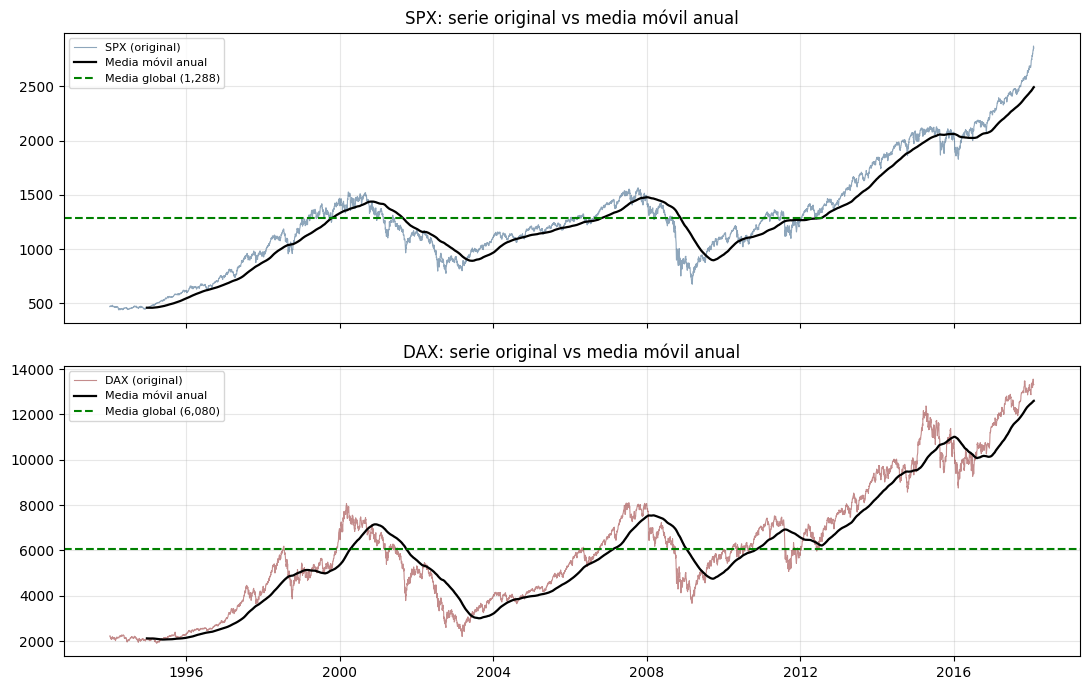

In [17]:
# ============================================================
# ESTACIONARIEDAD EN MEDIA (paso 7, primer punto)
# Superponemos serie original + media móvil + media global.
# Si fuese estacionaria, la media móvil oscilaría alrededor
# de la media global. Veremos que la cruza una vez y sigue subiendo.
# ============================================================
ventana = 252   # sesiones bursátiles de un año (no 365: no se cotiza fines de semana)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)   # ejes X compartidos

for ax, col, idx, color in [(axes[0],'spx','SPX','#1f4e79'),
                             (axes[1],'dax','DAX','#8b1a1a')]:
    # Serie original, atenuada para que no tape la media móvil
    ax.plot(df.index, df[col], label=f'{idx} (original)', color=color, linewidth=0.8, alpha=0.5)
    # Media móvil: suaviza el ruido diario y muestra el nivel medio
    ax.plot(df.index, df[col].rolling(ventana).mean(), label='Media móvil anual',
            color='black', linewidth=1.6)
    # Media global de toda la muestra
    ax.axhline(df[col].mean(), color='green', linestyle='--',
               label=f'Media global ({df[col].mean():,.0f})')
    ax.set_title(f'{idx}: serie original vs media móvil anual')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### Interpretación de la estacionariedad en media

Ni el SPX ni el DAX son estacionarios en media. La evidencia es concluyente:

- La media móvil anual (línea negra) crece de forma sistemática a lo largo del período en ambos índices, sin revertir hacia ningún nivel de referencia.
- La media global (línea verde discontinua) no es representativa de ningún tramo concreto de la serie: queda muy por encima de los valores de los años noventa y muy por debajo de los del último ciclo.

En una serie estacionaria en media, la serie oscilaría alrededor de un nivel fijo y la media global sería un estadístico informativo. Aquí la media móvil cruza la media global una sola vez y continúa ascendiendo.

**¿Es este comportamiento habitual en índices bursátiles? ¿Por qué?**

Sí, es el comportamiento **esperado y normal**, y responde a tres razones de fondo.

Primera, económica: los índices bursátiles recogen el valor de mercado de empresas cuyos beneficios crecen nominalmente con la economía. A largo plazo el precio de las acciones refleja el valor actual de flujos futuros que crecen con el PIB nominal y la inflación. Una serie de precios sin tendencia implicaría empresas que no generan valor a largo plazo.

Segunda, monetaria: la inflación acumulada erosiona el poder adquisitivo del denominador. Un índice expresado en términos nominales incorpora esa deriva de forma automática.

Tercera, y la más relevante desde el punto de vista teórico: la evidencia empírica sugiere que los precios bursátiles se comportan aproximadamente como un **paseo aleatorio con deriva** (random walk with drift):

$$P_t = \mu + P_{t-1} + \varepsilon_t$$

Este proceso contiene una **raíz unitaria** y es no estacionario por construcción. Su varianza crece con el tiempo y los shocks tienen efecto permanente sobre el nivel. Esta propiedad es coherente con la hipótesis de eficiencia de los mercados en su forma débil: si el precio de mañana fuese predecible a partir del de hoy, el arbitraje eliminaría esa oportunidad de inmediato.

**Implicación práctica para la modelización**

Esta no estacionariedad tiene una consecuencia directa: **los modelos ARIMA y GARCH no pueden aplicarse sobre los precios en niveles**. Es necesario transformar previamente la serie mediante **rendimientos logarítmicos**:

$$r_t = \ln(P_t) - \ln(P_{t-1})$$

Esta transformación —una diferenciación de primer orden sobre el logaritmo— elimina la tendencia y produce una serie que sí oscila en torno a una media próxima a cero. Es exactamente el término *Integrated* de las siglas ARIMA: el parámetro *d* del modelo ARIMA(p,d,q) indica cuántas diferenciaciones son necesarias para alcanzar la estacionariedad. Para índices bursátiles, d = 1 es lo habitual.

### 7.2. Estacionariedad en varianza

Siguiendo el enunciado, se divide el conjunto de datos en tres subconjuntos correspondientes a períodos distintos y se calcula la desviación típica de cada uno:

- **1994-2000** — expansión de las puntocom
- **2001-2008** — estallido de la burbuja tecnológica y crisis financiera global
- **2009-2018** — recuperación con política monetaria expansiva

In [18]:
# ============================================================
# DIVISIÓN EN TRES PERÍODOS (paso 7, segundo punto)
# .loc con fechas es INCLUSIVO en ambos extremos
# ============================================================
df_p1 = df.loc['1994':'2000']   # expansión puntocom
df_p2 = df.loc['2001':'2008']   # burbuja tecnológica + crisis financiera
df_p3 = df.loc['2009':'2018']   # recuperación con política monetaria expansiva

# Verificamos que no falten ni se solapen años (deben sumar 6.269)
for nombre_p, sub in [('1994-2000', df_p1), ('2001-2008', df_p2), ('2009-2018', df_p3)]:
    print(f'{nombre_p}: {len(sub):>5} obs. ({sub.index.min().date()} a {sub.index.max().date()})')

1994-2000:  1821 obs. (1994-01-07 a 2000-12-29)
2001-2008:  2087 obs. (2001-01-01 a 2008-12-31)
2009-2018:  2361 obs. (2009-01-02 a 2018-01-29)


In [19]:
# ============================================================
# DESVIACIÓN TÍPICA POR PERÍODO -> estacionariedad en varianza
# ============================================================
filas = []
for nombre_p, sub in [('1994-2000', df_p1), ('2001-2008', df_p2), ('2009-2018', df_p3)]:
    filas.append({
        'Período': nombre_p,
        'N': len(sub),
        'Media SPX': sub['spx'].mean(),
        'Desv. típica SPX': sub['spx'].std(),
        # Añadimos el CV: la desv. típica sola engaña, porque el nivel
        # medio del SPX pasa de 913 a 1.666 puntos entre períodos
        'CV SPX (%)': sub['spx'].std() / sub['spx'].mean() * 100,
        'Media DAX': sub['dax'].mean(),
        'Desv. típica DAX': sub['dax'].std(),
        'CV DAX (%)': sub['dax'].std() / sub['dax'].mean() * 100,
    })

tabla = pd.DataFrame(filas).set_index('Período')
tabla.T

# RESULTADO CONTRAINTUITIVO: 2001-2008 tiene la MENOR desv. típica del SPX
# pese a contener los dos mayores desplomes. Motivo: la desv. típica sobre
# NIVELES mide cuánto se desplazó el precio, no cuánta turbulencia hubo.
# Las caídas devolvieron el índice a su punto de partida -> recorrido neto bajo.

Período,1994-2000,2001-2008,2009-2018
N,"1,821.00","2,087.00","2,361.00"
Media SPX,913.10,"1,187.31","1,666.50"
Desv. típica SPX,355.97,180.16,494.24
CV SPX (%),38.98,15.17,29.66
Media DAX,"4,010.30","5,149.77","8,498.77"
Desv. típica DAX,"1,794.85","1,430.83","2,435.54"
CV DAX (%),44.76,27.78,28.66


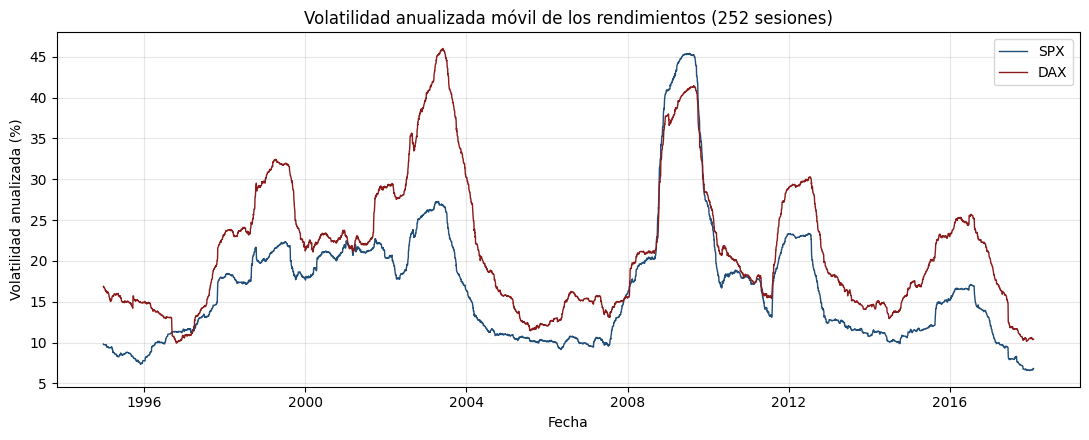

Volatilidad anualizada media por período:
  1994-2000: SPX 16.06%  |  DAX 20.96%
  2001-2008: SPX 21.13%  |  DAX 26.45%
  2009-2018: SPX 16.29%  |  DAX 20.53%


In [20]:
# ============================================================
# VOLATILIDAD SOBRE RENDIMIENTOS — la medida correcta
# Corrige el resultado engañoso de la celda anterior
# ============================================================

# Rendimiento logarítmico: ln(P_t) - ln(P_t-1) ≈ variación % diaria
# dropna() elimina la primera fila (no tiene día anterior)
rend = np.log(df[['spx','dax']]).diff().dropna()

# std() sobre rendimientos = volatilidad real de mercado
# sqrt(252) ANUALIZA: la volatilidad escala con la RAÍZ del tiempo,
# no linealmente. Multiplicar por 252 sería un error.
vol = rend.rolling(252).std() * np.sqrt(252) * 100

plt.figure(figsize=(11, 4.5))
plt.plot(vol.index, vol['spx'], label='SPX', color='#1f4e79', linewidth=1)
plt.plot(vol.index, vol['dax'], label='DAX', color='#8b1a1a', linewidth=1)
plt.title('Volatilidad anualizada móvil de los rendimientos (252 sesiones)')
plt.xlabel('Fecha'); plt.ylabel('Volatilidad anualizada (%)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

print('Volatilidad anualizada media por período:')
for nombre_p, ini, fin in [('1994-2000','1994','2000'), ('2001-2008','2001','2008'), ('2009-2018','2009','2018')]:
    s = rend.loc[ini:fin]
    print(f'  {nombre_p}: SPX {s["spx"].std()*np.sqrt(252)*100:5.2f}%  |  DAX {s["dax"].std()*np.sqrt(252)*100:5.2f}%')

# La lectura se INVIERTE y ahora tiene sentido económico:
# 2001-2008 pasa a ser el período MÁS volátil (SPX 21,13%, DAX 26,45%).
# El gráfico muestra VOLATILITY CLUSTERING: picos agrupados en 2002-03
# y 2008-09, y calma prolongada en 2013-17. Ese es el hecho empírico
# que motiva GARCH: ARIMA asume varianza constante y no puede capturarlo.

### Interpretación de la estacionariedad en varianza

| Período | Desv. típica SPX | CV SPX | Desv. típica DAX | CV DAX |
|---|---|---|---|---|
| 1994-2000 | 355,97 | 38,98% | 1.794,85 | 44,76% |
| 2001-2008 | 180,16 | 15,17% | 1.430,83 | 27,78% |
| 2009-2018 | 494,24 | 29,66% | 2.435,54 | 28,66% |

**Las series no son estacionarias en varianza.** La desviación típica del SPX varía entre 180,16 y 494,24 puntos según el período, es decir, se multiplica por 2,7 entre el tramo de menor y el de mayor dispersión. En el DAX el recorrido va de 1.430,83 a 2.435,54.

**Advertencia metodológica**

Estos resultados exigen una lectura cuidadosa, porque **la desviación típica calculada sobre niveles de precio no mide realmente volatilidad de mercado**: mide sobre todo cuánto se ha desplazado el nivel de la serie dentro de cada ventana. Un período con fuerte tendencia alcista y mercado tranquilo arroja una desviación típica alta simplemente porque el precio ha recorrido mucho terreno.

El caso del período 2001-2008 lo ilustra perfectamente. Es el tramo que contiene los dos mayores desplomes de la muestra —el estallido de las puntocom y la crisis de 2008— y, sin embargo, presenta la **menor** desviación típica del SPX (180,16). El motivo es que la caída de 2001-2003 y la de 2008 dejaron el índice aproximadamente en el nivel en el que empezó, de modo que el recorrido neto fue reducido pese a la enorme turbulencia intermedia.

**La medida correcta: volatilidad de los rendimientos**

Al calcular la volatilidad anualizada sobre los rendimientos logarítmicos, la lectura se invierte y se vuelve económicamente coherente:

| Período | Volatilidad SPX | Volatilidad DAX |
|---|---|---|
| 1994-2000 | 16,06% | 20,96% |
| **2001-2008** | **21,13%** | **26,45%** |
| 2009-2018 | 16,29% | 20,53% |

El período 2001-2008 pasa a ser el de mayor volatilidad en ambos índices, tal y como cabe esperar del tramo que concentra dos crisis sistémicas.

El gráfico de volatilidad móvil evidencia además el fenómeno de **agrupación de volatilidad** (volatility clustering): los períodos de alta volatilidad se concentran en bloques temporales, con picos muy marcados en 2002-2003 y en 2008-2009, seguidos de tramos prolongados de calma como el de 2013-2017. Los períodos turbulentos van seguidos de períodos turbulentos, y los tranquilos de tranquilos.

**Conexión con la modelización**

Esta agrupación de volatilidad es precisamente el hecho estilizado que motiva el uso de los modelos de la familia **ARCH/GARCH**. Un modelo ARIMA asume varianza constante en los residuos y es incapaz de capturar este comportamiento: ARIMA modela la media condicional, mientras que GARCH modela la **varianza condicional**, permitiendo que evolucione en el tiempo en función de los shocks pasados.

La práctica habitual en finanzas cuantitativas es combinar ambos enfoques —**ARIMA-GARCH**— para modelar simultáneamente el nivel del rendimiento y su volatilidad.

Desde mi perspectiva profesional en banca, esta distinción tiene consecuencias directas sobre la medición del riesgo. Un VaR paramétrico calculado con volatilidad constante infravalora sistemáticamente el riesgo en fases de estrés, que es justo cuando la métrica debería ser fiable. Es una de las debilidades que la normativa de Basilea intenta corregir exigiendo modelos con volatilidad condicional y pruebas de tensión.

## 8. Conclusiones

**Sobre los datos.** El conjunto contiene 6.269 observaciones diarias de cuatro índices bursátiles internacionales entre enero de 1994 y enero de 2018, sin valores ausentes ni duplicados. La serie recoge exclusivamente sesiones bursátiles, lo que introduce discontinuidades de calendario que deberán tenerse en cuenta al aplicar modelos que exijan frecuencia regular.

**Sobre el comportamiento descriptivo.** Ambos índices presentan tendencia alcista de largo plazo y distribución asimétrica positiva, con la media por encima de la mediana en los dos casos. El DAX muestra una dispersión relativa superior a la del SPX (coeficiente de variación del 45,30% frente al 37,85%), coherente con su menor diversificación: 30 valores frente a 500. La correlación entre ambos alcanza 0,9719, aunque una parte sustancial es espuria y atribuible a la tendencia común.

**Sobre la estacionariedad.** Ninguna de las dos series es estacionaria, ni en media ni en varianza. La media móvil crece sistemáticamente sin revertir a ningún nivel de referencia, y la desviación típica varía de forma sustancial entre subperíodos. Este resultado no es una anomalía de los datos, sino el comportamiento esperado en precios bursátiles, consistente con un proceso de paseo aleatorio con deriva.

**Sobre las implicaciones para la modelización.** La consecuencia operativa es que cualquier modelo ARIMA o GARCH debe aplicarse sobre rendimientos logarítmicos y no sobre niveles de precio. La transformación mediante diferenciación logarítmica elimina la tendencia y produce una serie estacionaria en media. La estacionariedad en varianza, en cambio, no se resuelve con la diferenciación: la agrupación de volatilidad persiste en los rendimientos y exige modelización explícita mediante GARCH.

**Valoración personal.** Desde mi experiencia como asesor patrimonial, el hallazgo con mayor aplicación práctica es la caída prácticamente idéntica de ambos índices en 2008 —48,01% en el SPX y 48,08% en el DAX— con mínimos separados por un solo día de negociación. Es la demostración empírica de que la diversificación geográfica dentro de renta variable desarrollada ofrece mucha menos protección de la que habitualmente se le atribuye en la conversación con el cliente. En episodios de estrés sistémico las correlaciones convergen hacia la unidad y la cobertura buscada desaparece justo en el momento en que resultaba necesaria. Trasladar esta realidad al cliente, con datos, es parte del trabajo de gestión de expectativas que precede a cualquier decisión de asignación de activos.